# Product analytics: acquisition, activity, and retention

This notebook develops a descriptive view of the sample App Service customer data: who was acquired, when accounts were created, how many accounts had observed usage over time, and how frequently recently acquired accounts returned.

**Retention definition:** D7 and D30 are account-level indicators for at least one observed usage record in days 7–13 or days 30–36 after the account's creation date (inclusive). Each denominator includes only accounts whose full seven-day window falls within the usage extract's observed date range. Acquisition cohorts are defined using the supplied Sunday-start creation-week key.

**Interpretation limits:** The usage file records observed account-days, not confirmed inactivity on dates without a row. An account with no record in a retention window is therefore classified as having no *observed* usage in that window, not as definitively churned. The extract ends on 2022-04-30; no retention window extending beyond that date is counted. These are descriptive summaries of this sample, not causal or inferential results.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})


## Load and validate the three case datasets

In [2]:
source_files = [
    "Case_AccountData.csv",
    "Case_AccountCreation.csv",
    "Case_UsageData.csv",
]
search_roots = [Path.cwd(), *Path.cwd().parents]
data_dir = next(
    (root for root in search_roots if all((root / name).is_file() for name in source_files)),
    None,
)
if data_dir is None:
    raise FileNotFoundError(
        "Could not locate all three case CSV files from the notebook's working directory."
    )

account_data = pd.read_csv(data_dir / source_files[0])
creation = pd.read_csv(data_dir / source_files[1])
usage = pd.read_csv(data_dir / source_files[2])

for frame, column in [
    (creation, "AccountCreatedDay"),
    (creation, "AccountCreatedWeek"),
    (usage, "UsageDate"),
]:
    frame[column] = pd.to_datetime(frame[column], utc=True).dt.tz_convert(None).dt.normalize()

assert account_data["AccountID"].is_unique, "Account data should have one row per account."
assert creation["AccountID"].is_unique, "Creation data should have one row per account."
assert not usage.duplicated(["AccountID", "UsageDate"]).any(), "Usage should have one row per observed account-day."
assert not account_data.isna().any().any(), "Account data contains missing values."
assert not creation.isna().any().any(), "Creation data contains missing values."
assert not usage.isna().any().any(), "Usage data contains missing values."
assert set(account_data["AccountID"]) == set(creation["AccountID"]), "Account and creation IDs do not match."
assert set(usage["AccountID"]).issubset(set(account_data["AccountID"])), "Usage includes an unknown account."
assert set(account_data["AccountID"]).issubset(set(usage["AccountID"])), "Some accounts have no observed usage in the extract."

accounts = account_data.merge(creation, on="AccountID", how="inner", validate="one_to_one")
usage_start = usage["UsageDate"].min()
usage_end = usage["UsageDate"].max()

data_quality = pd.DataFrame(
    [
        {
            "Dataset": "Account attributes",
            "Rows": len(account_data),
            "Distinct accounts": account_data["AccountID"].nunique(),
            "Observed date range": "Not applicable",
            "Missing values": int(account_data.isna().sum().sum()),
        },
        {
            "Dataset": "Account creation",
            "Rows": len(creation),
            "Distinct accounts": creation["AccountID"].nunique(),
            "Observed date range": f"{creation['AccountCreatedDay'].min():%Y-%m-%d} to {creation['AccountCreatedDay'].max():%Y-%m-%d}",
            "Missing values": int(creation.isna().sum().sum()),
        },
        {
            "Dataset": "Observed usage",
            "Rows": len(usage),
            "Distinct accounts": usage["AccountID"].nunique(),
            "Observed date range": f"{usage_start:%Y-%m-%d} to {usage_end:%Y-%m-%d}",
            "Missing values": int(usage.isna().sum().sum()),
        },
    ]
)
display(data_quality)
print(
    f"Join check: {len(accounts):,} account records after a one-to-one join; "
    f"all {accounts['AccountID'].nunique():,} accounts have at least one observed usage row."
)
print(
    f"Usage grain: {len(usage):,} observed account-days across "
    f"{usage['UsageDate'].nunique()} calendar dates. A missing account-date row is unobserved, "
    "not independently verified inactivity."
)


,Dataset,Rows,Distinct accounts,Observed date range,Missing values
0,Account attributes,977,977,Not applicable,0
1,Account creation,977,977,2022-02-01 to 2022-02-27,0
2,Observed usage,44352,977,2022-02-01 to 2022-04-30,0


Join check: 977 account records after a one-to-one join; all 977 accounts have at least one observed usage row.
Usage grain: 44,352 observed account-days across 89 calendar dates. A missing account-date row is unobserved, not independently verified inactivity.


## Acquisition timing

The day-level chart shows the supplied account-creation records by creation date. The weekly view uses the dataset's Sunday-start week keys, so the first and last cohorts can be partial weeks. Counts describe the 977 accounts in this extract, not a population-wide acquisition rate.

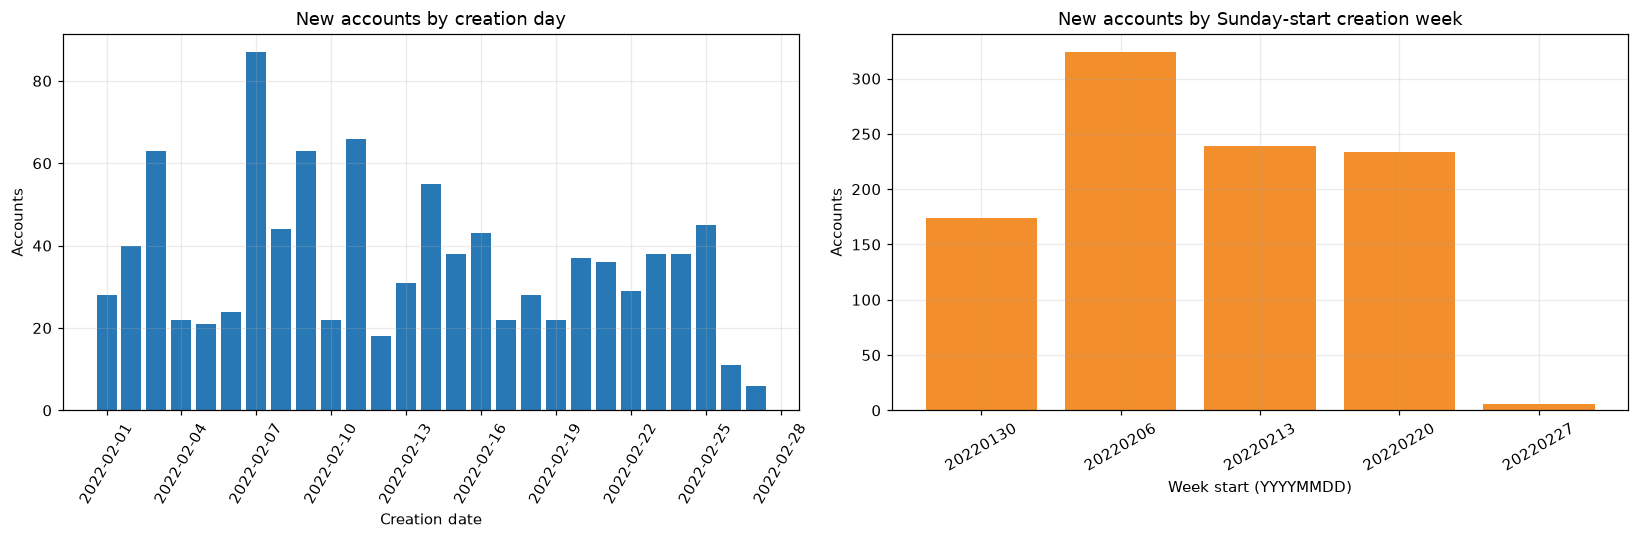

,AccountCreatedWeek_Key,Accounts
0,20220130,174
1,20220206,324
2,20220213,239
3,20220220,234
4,20220227,6


In [3]:
daily_acquisitions = (
    creation.groupby("AccountCreatedDay", as_index=False)
    .agg(Accounts=("AccountID", "nunique"))
    .sort_values("AccountCreatedDay")
)
weekly_acquisitions = (
    creation.groupby("AccountCreatedWeek_Key", as_index=False)
    .agg(Accounts=("AccountID", "nunique"))
    .sort_values("AccountCreatedWeek_Key")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(daily_acquisitions["AccountCreatedDay"], daily_acquisitions["Accounts"], color="#2878B5")
axes[0].set(title="New accounts by creation day", xlabel="Creation date", ylabel="Accounts")
axes[0].tick_params(axis="x", rotation=60)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(10))

axes[1].bar(weekly_acquisitions["AccountCreatedWeek_Key"].astype(str), weekly_acquisitions["Accounts"], color="#F28E2B")
axes[1].set(title="New accounts by Sunday-start creation week", xlabel="Week start (YYYYMMDD)", ylabel="Accounts")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

display(weekly_acquisitions)


## Customer composition

The categories are shown as supplied. `unknown` is an explicit development-language category in the extract; it is not silently recoded as missing.

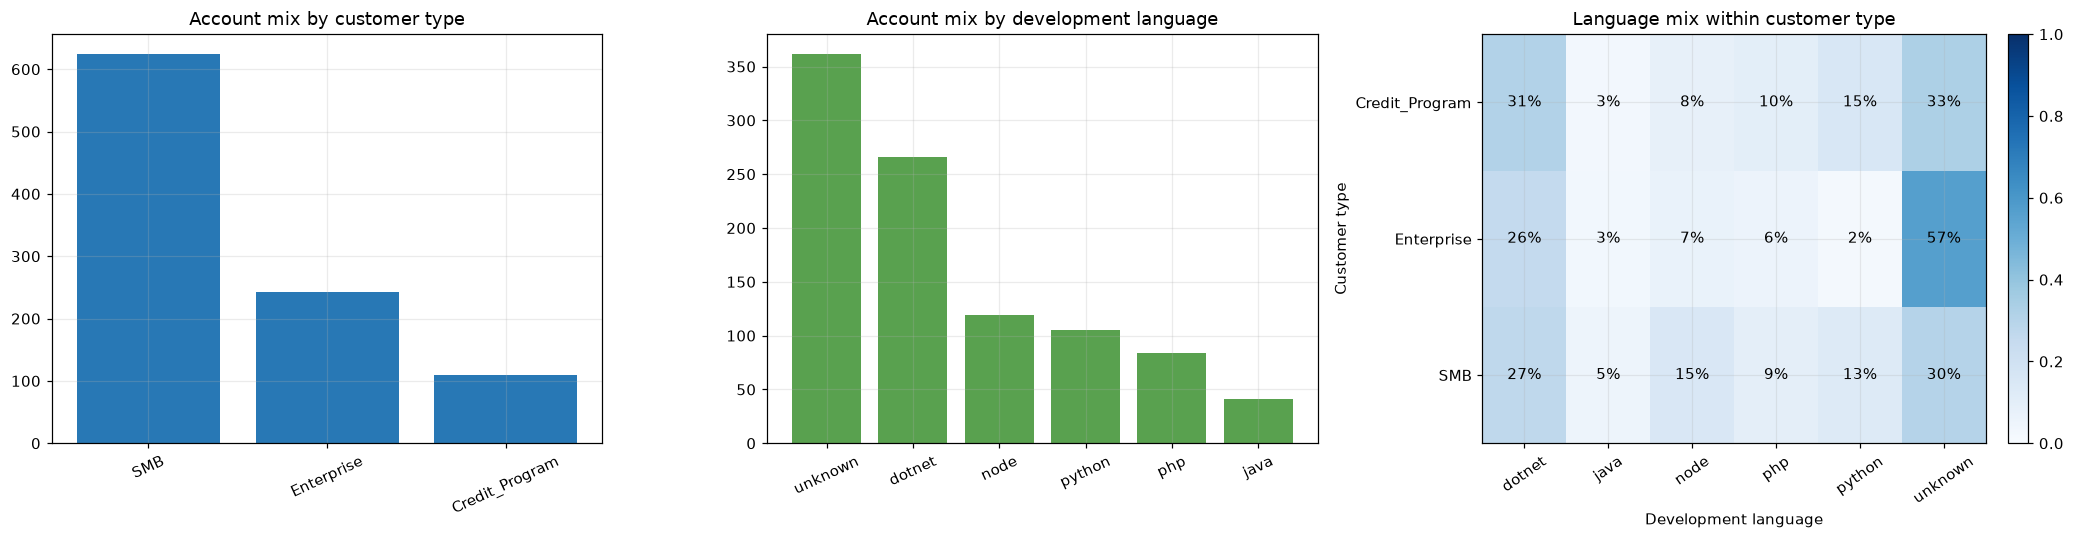

,Customer type,Accounts
0,SMB,625
1,Enterprise,242
2,Credit_Program,110


,Development language,Accounts
0,unknown,362
1,dotnet,266
2,node,119
3,python,105
4,php,84
5,java,41


In [4]:
customer_type_counts = account_data["CustomerType"].value_counts().rename_axis("Customer type").reset_index(name="Accounts")
language_counts = account_data["DevLanguage"].value_counts().rename_axis("Development language").reset_index(name="Accounts")
segment_language_share = pd.crosstab(
    account_data["CustomerType"], account_data["DevLanguage"], normalize="index"
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].bar(customer_type_counts["Customer type"], customer_type_counts["Accounts"], color="#2878B5")
axes[0].set_title("Account mix by customer type")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(language_counts["Development language"], language_counts["Accounts"], color="#59A14F")
axes[1].set_title("Account mix by development language")
axes[1].tick_params(axis="x", rotation=25)

image = axes[2].imshow(segment_language_share.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[2].set_xticks(range(len(segment_language_share.columns)), segment_language_share.columns)
axes[2].set_yticks(range(len(segment_language_share.index)), segment_language_share.index)
for row in range(segment_language_share.shape[0]):
    for column in range(segment_language_share.shape[1]):
        axes[2].text(
            column,
            row,
            f"{segment_language_share.iloc[row, column]:.0%}",
            ha="center",
            va="center",
            color="black",
        )
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set(title="Language mix within customer type", xlabel="Development language", ylabel="Customer type")
axes[2].tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()

display(customer_type_counts)
display(language_counts)


## Observed daily usage

Daily active accounts are the distinct accounts with at least one row on each date; daily account-days are the total observed account-day rows. The active-account share below uses all 977 accounts in the joined sample as a fixed denominator. It is a sample coverage measure, not a population-wide product adoption rate.

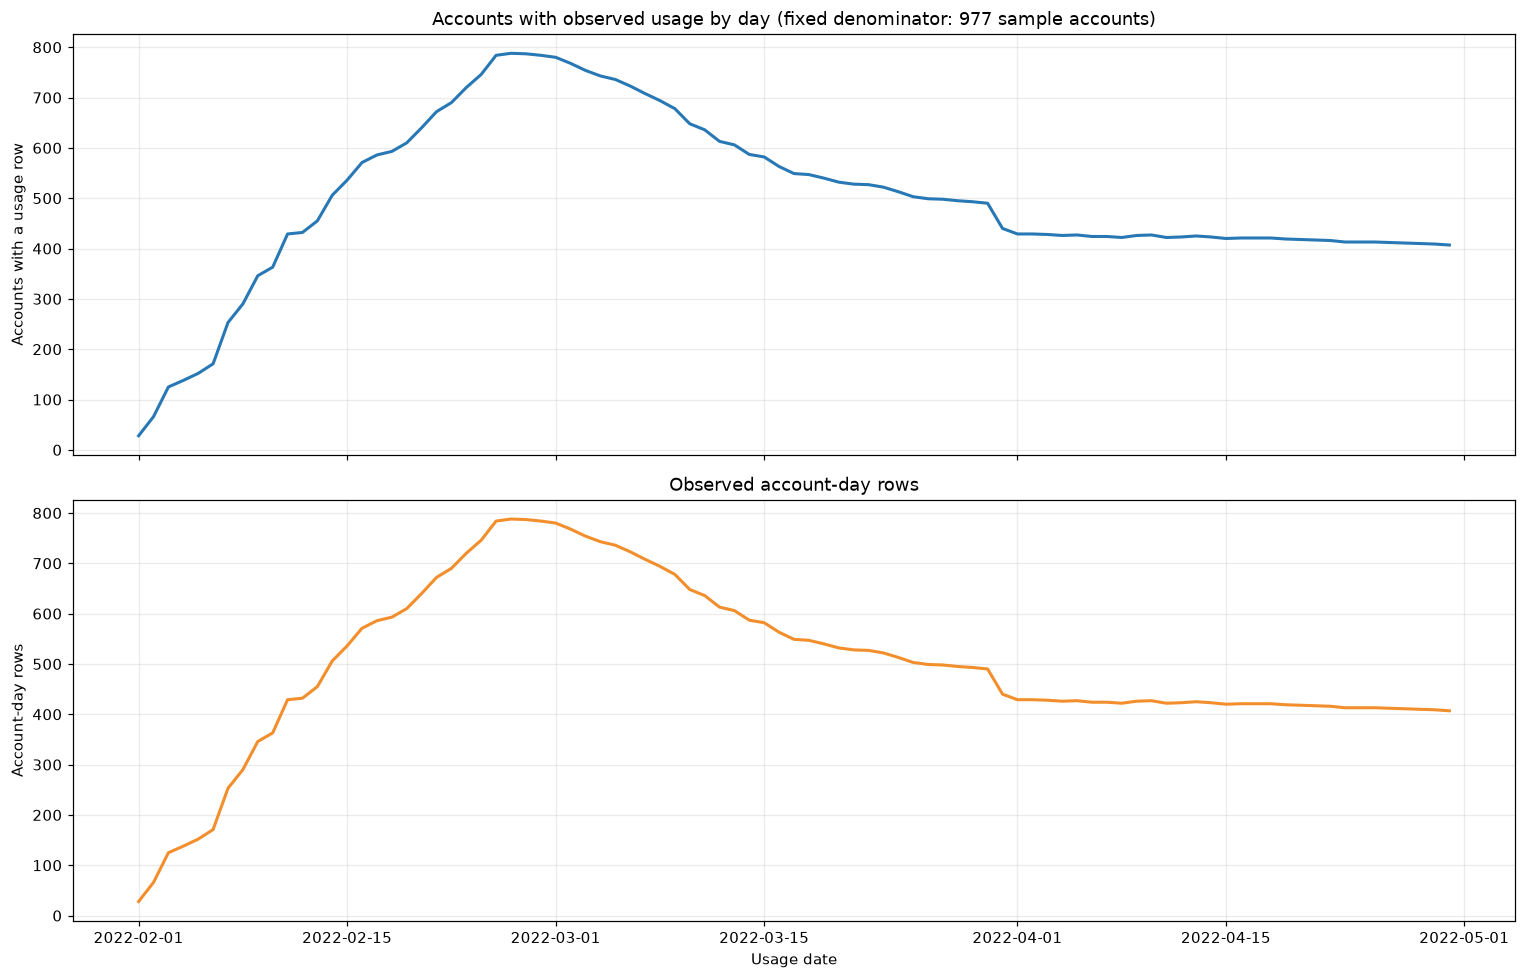

Observed daily active-account counts range from 28 to 788 of 977 accounts.


In [5]:
daily_usage = (
    usage.groupby("UsageDate")
    .agg(
        Active_accounts=("AccountID", "nunique"),
        Observed_account_days=("AccountID", "size"),
    )
    .reset_index()
    .sort_values("UsageDate")
)
total_accounts = accounts["AccountID"].nunique()
daily_usage["Share_of_sample_with_observed_usage"] = daily_usage["Active_accounts"] / total_accounts

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(daily_usage["UsageDate"], daily_usage["Active_accounts"], color="#2878B5", linewidth=2)
axes[0].set(
    title=f"Accounts with observed usage by day (fixed denominator: {total_accounts:,} sample accounts)",
    ylabel="Accounts with a usage row",
)
axes[1].plot(daily_usage["UsageDate"], daily_usage["Observed_account_days"], color="#F28E2B", linewidth=2)
axes[1].set(title="Observed account-day rows", xlabel="Usage date", ylabel="Account-day rows")
fig.tight_layout()
plt.show()

print(
    f"Observed daily active-account counts range from {daily_usage['Active_accounts'].min():,} "
    f"to {daily_usage['Active_accounts'].max():,} of {total_accounts:,} accounts."
)


## Account-level observed usage frequency

,Observed usage days
count,977.000
mean,45.396
std,29.081
min,1.000
25%,28.000
50%,36.000
75%,74.000
max,89.000


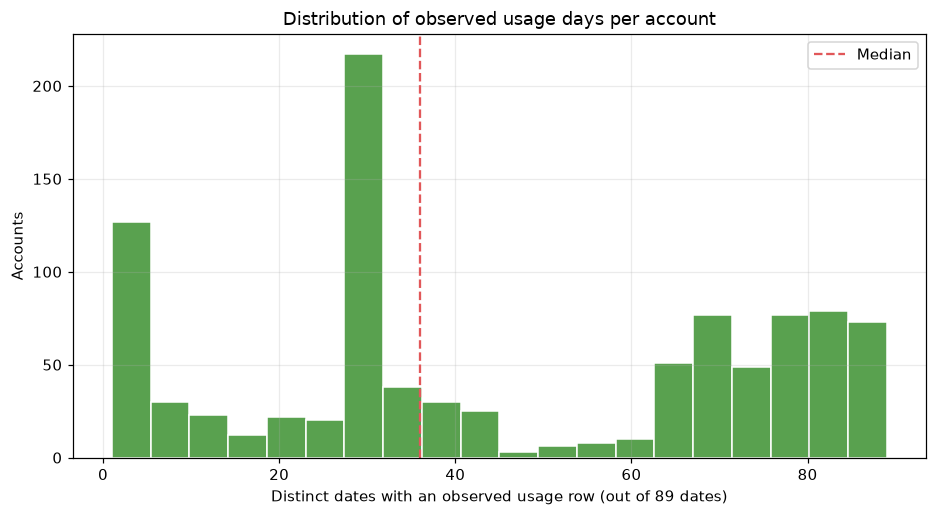

In [6]:
usage_days_per_account = (
    usage.groupby("AccountID")["UsageDate"]
    .nunique()
    .rename("Observed usage days")
    .reset_index()
)
usage_days_summary = usage_days_per_account["Observed usage days"].describe(
    percentiles=[0.25, 0.5, 0.75]
).to_frame("Observed usage days")
display(usage_days_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(usage_days_per_account["Observed usage days"], bins=20, color="#59A14F", edgecolor="white")
ax.axvline(usage_days_per_account["Observed usage days"].median(), color="#E15759", linestyle="--", label="Median")
ax.set(
    title="Distribution of observed usage days per account",
    xlabel="Distinct dates with an observed usage row (out of 89 dates)",
    ylabel="Accounts",
)
ax.legend()
plt.show()


## D7 and D30 observed-usage retention

For each account, the D7 window is creation date + 7 through +13 days, and D30 is creation date + 30 through +36 days. A numerator account has at least one observed usage row in that window. The denominator includes accounts only when the entire corresponding window is between the first and last dates represented in the usage extract. Grouped percentages are therefore comparable only within the displayed eligible cohort, and small cohort sizes should be read cautiously.

,D7 retained,D7 eligible,D7 rate,D30 retained,D30 eligible,D30 rate
0,829,977,0.849,594,977,0.608


,AccountCreatedWeek_Key,D7 retained,D7 eligible,D7 rate,D30 retained,D30 eligible,D30 rate
0,20220130,144,174,0.828,101,174,0.580
1,20220206,282,324,0.870,200,324,0.617
2,20220213,196,239,0.820,138,239,0.577
3,20220220,202,234,0.863,151,234,0.645
4,20220227,5,6,0.833,4,6,0.667


,CustomerType,D7 retained,D7 eligible,D7 rate,D30 retained,D30 eligible,D30 rate
0,Credit_Program,77,110,0.700,73,110,0.664
1,Enterprise,224,242,0.926,217,242,0.897
2,SMB,528,625,0.845,304,625,0.486


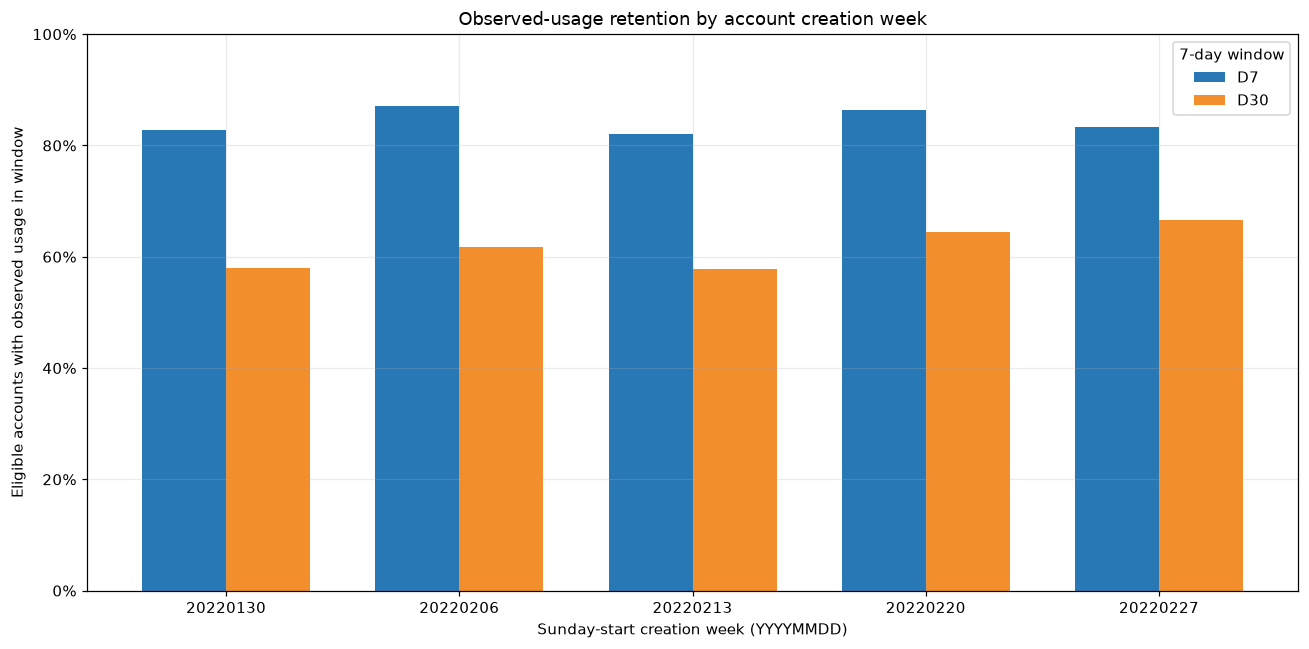

In [7]:
retention_accounts = accounts[["AccountID", "CustomerType", "DevLanguage", "AccountCreatedDay", "AccountCreatedWeek_Key"]].copy()

for label, offset_days in [("D7", 7), ("D30", 30)]:
    retention_accounts[f"{label}_window_start"] = retention_accounts["AccountCreatedDay"] + pd.to_timedelta(offset_days, unit="D")
    retention_accounts[f"{label}_window_end"] = retention_accounts[f"{label}_window_start"] + pd.to_timedelta(6, unit="D")
    retention_accounts[f"{label}_eligible"] = (
        retention_accounts[f"{label}_window_start"].ge(usage_start)
        & retention_accounts[f"{label}_window_end"].le(usage_end)
    )

    in_window = usage.merge(
        retention_accounts[["AccountID", "AccountCreatedDay", f"{label}_window_start", f"{label}_window_end"]],
        on="AccountID",
        how="inner",
        validate="many_to_one",
    )
    observed_ids = set(
        in_window.loc[
            in_window["UsageDate"].between(
                in_window[f"{label}_window_start"],
                in_window[f"{label}_window_end"],
                inclusive="both",
            ),
            "AccountID",
        ]
    )
    retention_accounts[f"{label}_retained"] = (
        retention_accounts[f"{label}_eligible"]
        & retention_accounts["AccountID"].isin(observed_ids)
    )

def summarize_retention(frame, cohort_column=None):
    group_columns = [cohort_column] if cohort_column else []
    grouped = frame.groupby(group_columns, dropna=False) if group_columns else [(None, frame)]
    records = []
    for key, group in grouped:
        group_key = key[0] if isinstance(key, tuple) else key
        record = {cohort_column: group_key} if cohort_column else {}
        for label in ["D7", "D30"]:
            eligible = group.loc[group[f"{label}_eligible"]]
            denominator = len(eligible)
            numerator = int(eligible[f"{label}_retained"].sum())
            record[f"{label} retained"] = numerator
            record[f"{label} eligible"] = denominator
            record[f"{label} rate"] = numerator / denominator if denominator else np.nan
        records.append(record)
    return pd.DataFrame(records)

overall_retention = summarize_retention(retention_accounts)
retention_by_creation_week = summarize_retention(retention_accounts, "AccountCreatedWeek_Key")
retention_by_customer_type = summarize_retention(retention_accounts, "CustomerType")

display(overall_retention)
display(retention_by_creation_week)
display(retention_by_customer_type)

retention_plot = retention_by_creation_week.melt(
    id_vars="AccountCreatedWeek_Key",
    value_vars=["D7 rate", "D30 rate"],
    var_name="Window",
    value_name="Observed-usage retention rate",
)
fig, ax = plt.subplots(figsize=(12, 6))
cohort_labels = retention_by_creation_week["AccountCreatedWeek_Key"].astype(str).tolist()
positions = np.arange(len(cohort_labels))
bar_width = 0.36
for offset, (window, color) in enumerate([("D7 rate", "#2878B5"), ("D30 rate", "#F28E2B")]):
    rates = retention_by_creation_week[window].to_numpy()
    ax.bar(
        positions + (offset - 0.5) * bar_width,
        rates,
        width=bar_width,
        label=window.replace(" rate", ""),
        color=color,
    )
ax.set(
    title="Observed-usage retention by account creation week",
    xlabel="Sunday-start creation week (YYYYMMDD)",
    ylabel="Eligible accounts with observed usage in window",
    ylim=(0, 1),
)
ax.set_xticks(positions, cohort_labels)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f"{value:.0%}"))
ax.legend(title="7-day window")
fig.tight_layout()
plt.show()


## Initial descriptive findings

The statements below are generated from this extract. They summarize observed records only and should not be presented as causal explanations or as validated business outcomes.

In [8]:
peak_acquisition = daily_acquisitions.loc[daily_acquisitions["Accounts"].idxmax()]
largest_week = weekly_acquisitions.loc[weekly_acquisitions["Accounts"].idxmax()]
peak_usage = daily_usage.loc[daily_usage["Active_accounts"].idxmax()]
segment_shares = account_data["CustomerType"].value_counts(normalize=True)
language_unknown_share = account_data["DevLanguage"].eq("unknown").mean()
overall = overall_retention.iloc[0]

print(
    f"Acquisition: {len(accounts):,} accounts were created from "
    f"{creation['AccountCreatedDay'].min():%Y-%m-%d} through {creation['AccountCreatedDay'].max():%Y-%m-%d}. "
    f"The busiest supplied creation date was {peak_acquisition['AccountCreatedDay']:%Y-%m-%d} "
    f"({int(peak_acquisition['Accounts'])} accounts); the largest Sunday-start cohort was "
    f"{largest_week['AccountCreatedWeek_Key']} ({int(largest_week['Accounts'])} accounts)."
)
print(
    f"Composition: {segment_shares.index[0]} is the largest customer-type group "
    f"({segment_shares.iloc[0]:.1%} of sample accounts). `unknown` represents "
    f"{language_unknown_share:.1%} of the supplied development-language values."
)
print(
    f"Observed activity: the highest daily count was {int(peak_usage['Active_accounts'])} accounts "
    f"({peak_usage['Active_accounts'] / total_accounts:.1%} of the {total_accounts:,}-account sample) "
    f"on {peak_usage['UsageDate']:%Y-%m-%d}. No-row dates are not treated as independently confirmed inactivity."
)
print(
    f"Retention: D7 {int(overall['D7 retained'])}/{int(overall['D7 eligible'])} "
    f"({overall['D7 rate']:.1%}); D30 {int(overall['D30 retained'])}/{int(overall['D30 eligible'])} "
    f"({overall['D30 rate']:.1%}). Rates use eligible accounts and require at least one observed "
    "usage row in the defined seven-day window."
)
type_d30 = retention_by_customer_type.sort_values("D30 rate")
lowest_type = type_d30.iloc[0]
highest_type = type_d30.iloc[-1]
print(
    f"Descriptive segment comparison: D30 observed-usage retention ranges from "
    f"{lowest_type['D30 rate']:.1%} for {lowest_type['CustomerType']} "
    f"({int(lowest_type['D30 retained'])}/{int(lowest_type['D30 eligible'])}) to "
    f"{highest_type['D30 rate']:.1%} for {highest_type['CustomerType']} "
    f"({int(highest_type['D30 retained'])}/{int(highest_type['D30 eligible'])}). "
    "This describes differences in this sample; it does not explain their causes."
)


Acquisition: 977 accounts were created from 2022-02-01 through 2022-02-27. The busiest supplied creation date was 2022-02-07 (87 accounts); the largest Sunday-start cohort was 20220206 (324 accounts).
Composition: SMB is the largest customer-type group (64.0% of sample accounts). `unknown` represents 37.1% of the supplied development-language values.
Observed activity: the highest daily count was 788 accounts (80.7% of the 977-account sample) on 2022-02-26. No-row dates are not treated as independently confirmed inactivity.
Retention: D7 829/977 (84.9%); D30 594/977 (60.8%). Rates use eligible accounts and require at least one observed usage row in the defined seven-day window.
Descriptive segment comparison: D30 observed-usage retention ranges from 48.6% for SMB (304/625) to 89.7% for Enterprise (217/242). This describes differences in this sample; it does not explain their causes.


## Questions to validate with the product team

- Does one row in the usage extract represent a complete, consistently captured product-usage day for every account, or are instrumentation and ingestion coverage uneven?
- Are these account creation dates and Sunday-start cohort keys the intended acquisition definitions, and are there known campaigns, eligibility rules, or operational changes behind high-volume dates?
- Is “at least one usage day in days 7–13 / 30–36” an appropriate retention definition for leadership, or should a qualified/meaningful usage event or another follow-up window be used?
- What business meaning should be assigned to `Credit_Program`, and can the `unknown` development-language category be resolved or segmented further?
- Are accounts that stop generating observed usage known to be churned, paused, migrated, or still using the product outside the extract's captured events?

These checks are needed before turning the descriptive patterns into performance conclusions or recommendations.